## Introduction
###### What is the Dataset?
###### This dataset contains information about 10,000 employees and job postings from various companies and countries. It includes details such as job titles, company names, locations, salary information, required skills, and employee benefits. The dataset also contains attributes related to remote work opportunities, health insurance availability, and educational requirements.
###### The purpose of this dataset is to explore employment trends, salary distributions, company hiring patterns, geographical differences in job opportunities, and the demand for specific skills across different roles. Through Exploratory Data Analysis (EDA), we aim to uncover meaningful insights and patterns that can help understand the job market and workforce characteristics.

## Dataset

In [72]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt  

# Load Data
df = pd.read_excel('data_for_10,000_employees.xlsx')

# Data Cleanup 
df['Job_posted_date'] = pd.to_datetime(df['Job_posted_date'])
df['Job_skills'] = df['Job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


## Dataset Overview

In [73]:
print("Dataset Shape:", df.shape)

Dataset Shape: (10000, 15)


##### Observation
###### The dataset contains 10,000 records and 15 features.

In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Name                   10000 non-null  str           
 1   Gender                 10000 non-null  str           
 2   Job                    10000 non-null  str           
 3   Company                10000 non-null  str           
 4   Country                10000 non-null  str           
 5   Salary                 10000 non-null  int64         
 6   Bonus_Rate             10000 non-null  float64       
 7   Total_Salary           10000 non-null  float64       
 8   Job_posted_date        10000 non-null  datetime64[us]
 9   Salary_hour_avg        4414 non-null   float64       
 10  Salary_year_avg        5436 non-null   float64       
 11  Job_skills             10000 non-null  object        
 12  job_work_from_home     10000 non-null  bool          
 13  job_no_degree

##### Observation
###### The dataset consists of numerical, categorical, boolean, and datetime features. Most columns have complete information, while salary-related columns contain missing values.

In [75]:
missing = df.isnull().sum()
missing[missing > 0]

Salary_hour_avg    5586
Salary_year_avg    4564
dtype: int64

##### Observation 
###### Two salary columns contain a significant number of missing values, while the remaining features are largely complete.

## Jobs to Explore

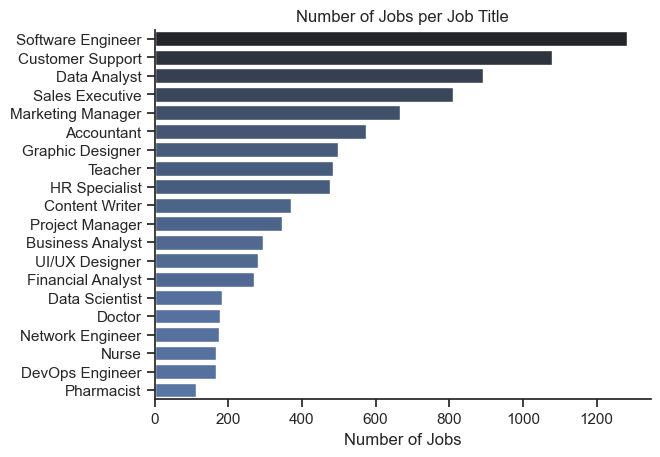

In [76]:
df_plot = df['Job'].value_counts().head(20).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y=df_plot.index, hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Number of Jobs per Job Title')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

## Countries to Explore

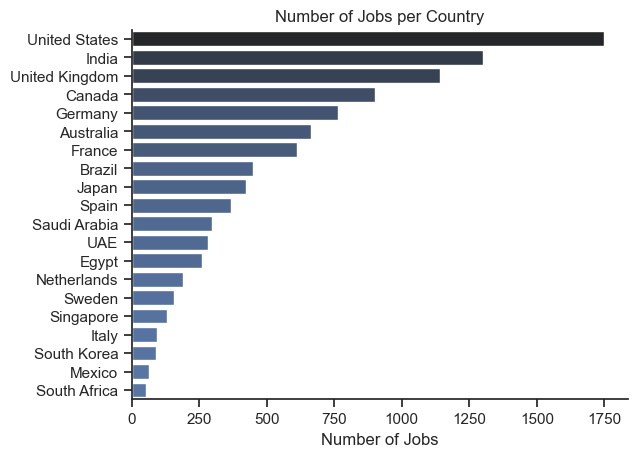

In [77]:
df_plot = df['Country'].value_counts().to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='Country', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Number of Jobs per Country')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

## Companies to Explore

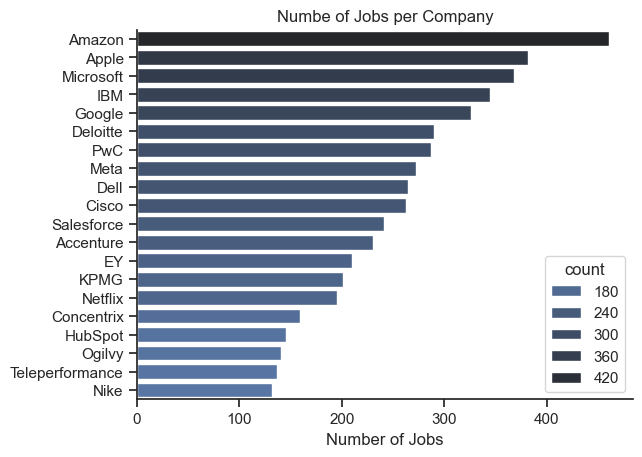

In [78]:
df_plot = df['Company'].value_counts().head(20).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='Company', hue='count', palette='dark:b_r')
sns.despine()
plt.title('Numbe of Jobs per Company')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

## Job Opportunities

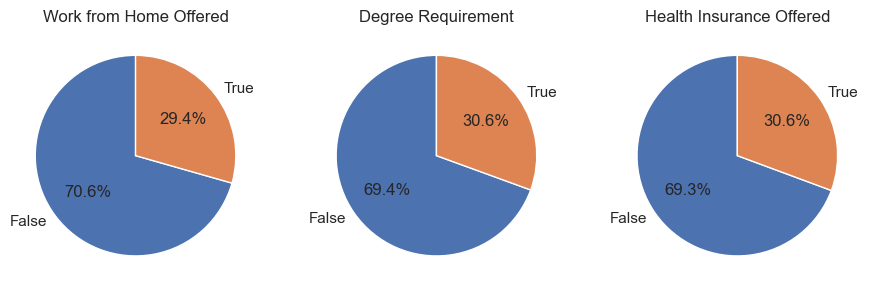

In [79]:
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3, figsize=(11, 3.5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df[column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

plt.show()

## Salary Analysis


In [83]:
df.describe()

,Salary,Bonus_Rate,Total_Salary,Job_posted_date,Salary_hour_avg,Salary_year_avg
count,10000.000000,10000.000000,10000.000000,10000,4414.000000,5436.000000
mean,55870.531800,0.135565,63438.625795,2025-05-28 06:24:54.720000,26.851155,56085.125022
min,18000.000000,0.050000,18900.000000,2024-10-15 00:00:00,9.000000,16644.120000
25%,37442.250000,0.100000,42201.225000,2025-02-05 00:00:00,18.000000,36927.742500
50%,50930.500000,0.150000,57750.000000,2025-05-27 00:00:00,24.000000,51221.185000
75%,69617.750000,0.150000,79023.762500,2025-09-19 00:00:00,33.000000,69999.105000
max,165000.000000,0.250000,198000.000000,2026-01-08 00:00:00,79.000000,168921.660000
std,24720.284017,0.055238,28252.152814,NaN,12.014694,25214.676234


##### Observation
###### The average annual salary is approximately $55,870, while the median salary is $50,930. The large difference between the minimum ($37,442) and maximum ($69,617) salaries indicates substantial variation in compensation levels across job roles. The high maximum value suggests the presence of outliers or highly paid specialized positions.

### Salary Histogram

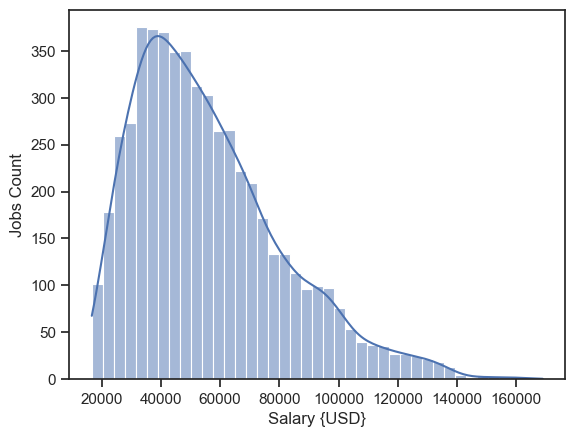

In [85]:
sns.histplot(df['Salary_year_avg'].dropna(), kde=True)
plt.xlabel('Salary {USD}')
plt.ylabel('Jobs Count')
plt.show()

### Top 10 Paying Jobs

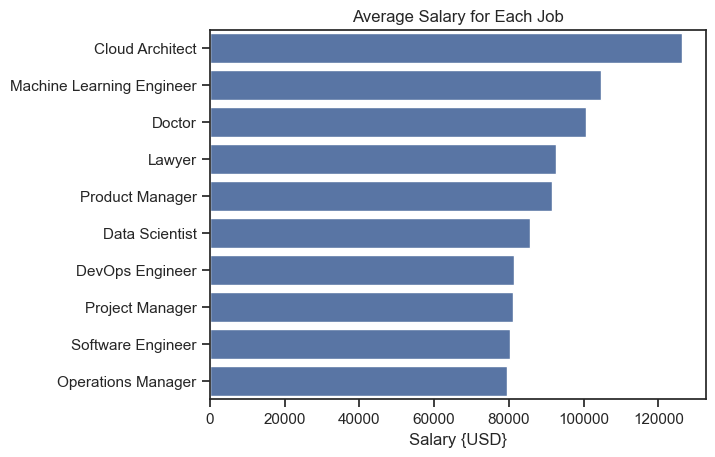

In [105]:
salary_job = df.groupby('Job')['Salary_year_avg'].mean().sort_values(ascending=False).head(10).to_frame()

sns.barplot(data=salary_job, x='Salary_year_avg', y=salary_job.index)
plt.title('Average Salary for Each Job')
plt.ylabel('')
plt.xlabel('Salary {USD}')
plt.show()

### Top 10 Paying Countries

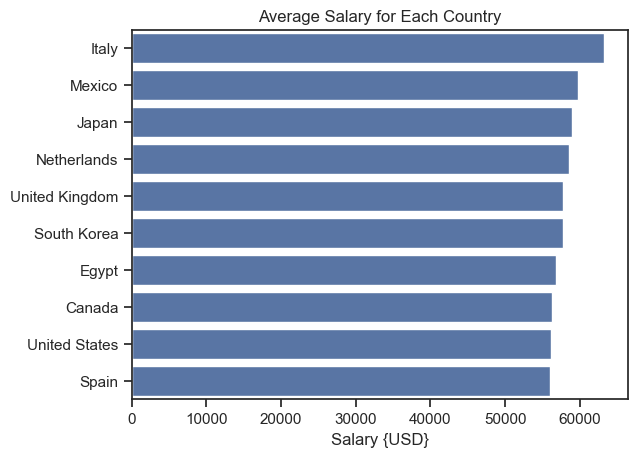

In [107]:
salary_country = (
    df.groupby('Country')['Salary_year_avg']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .to_frame()
)

sns.barplot(data=salary_country, x='Salary_year_avg', y=salary_country.index)
plt.title('Average Salary for Each Country')
plt.ylabel('')
plt.xlabel('Salary {USD}')
plt.show()